## Import librarys

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error
%matplotlib inline

## Getting the data

In [3]:
#Loading the datasets
df_diamonds = pd.read_csv('diamonds.csv')

In [4]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
df_diamonds.head()
columns = ['cut', 'color', 'clarity']
dict_unique = {}
for c in columns:
    dict_unique[c] = df_diamonds[c].unique()
print(dict_unique)

{'cut': array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object), 'color': array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object), 'clarity': array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)}


In [6]:
#To colum cut I will assing 0 at 5 by each value on the column
df_diamonds['cut'] = df_diamonds['cut'].map({'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4})

#Other way could be to use LabelEncoder from sklearn
# le = LabelEncoder()
# df_diamonds['cut_modify']  = le.fit_transform(df_diamonds['cut'] )

#To others columns with objects values, to not introduced the articial values
# df_base = pd.DataFrame()
for col in columns[1:]:
    # Starting the OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False)

    # Applying OneHotEncoder
    encoded_data = encoder.fit_transform(df_diamonds[[col]])

    # Converting the encoded data to a DataFrame
    encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([col]))
    
    # Concatenating the encoded DataFrame with the original DataFrame
    df_diamonds = pd.concat([df_diamonds, encoded_df], axis=1)

df_diamonds_done = df_diamonds.drop(columns=columns[1:], axis=1)

In [7]:
df_diamonds.head()
df_diamonds_done.columns
df_diamonds_done.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    53940 non-null  int64  
 1   carat         53940 non-null  float64
 2   cut           53940 non-null  int64  
 3   depth         53940 non-null  float64
 4   table         53940 non-null  float64
 5   price         53940 non-null  int64  
 6   x             53940 non-null  float64
 7   y             53940 non-null  float64
 8   z             53940 non-null  float64
 9   color_D       53940 non-null  float64
 10  color_E       53940 non-null  float64
 11  color_F       53940 non-null  float64
 12  color_G       53940 non-null  float64
 13  color_H       53940 non-null  float64
 14  color_I       53940 non-null  float64
 15  color_J       53940 non-null  float64
 16  clarity_I1    53940 non-null  float64
 17  clarity_IF    53940 non-null  float64
 18  clarity_SI1   53940 non-nu

## Division train-test

In [8]:
X = df_diamonds_done.drop('price', axis=1)
y = df_diamonds_done['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Standard Validations

In [9]:
#Standardization is not recommended for data with outliers
#1. Normalization: scales the data to a range of [0, 1]
scaler_normalized = MinMaxScaler()
normalized_data_train = scaler_normalized.fit_transform(X_train)
normalized_data_test = scaler_normalized.transform(X_test)

#2. Standardization: scales the data to a mean of 0 and a standard deviation of 1   
scaler_standard = StandardScaler()
standard_data_train = scaler_standard.fit_transform(X_train)
standard_data_test = scaler_standard.transform(X_test)

#3. RobustScaler: scales the data using statistics that are robust to outliers
scaler_robuster = RobustScaler()
robust_data_train = scaler_robuster.fit_transform(X_train)
robust_data_test = scaler_robuster.transform(X_test)

## Classification methods
Logistic Regression

Method: MinMaxScaler
Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:


c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

              precision    recall  f1-score   support

         335       0.00      0.00      0.00         1
         336       0.00      0.00      0.00         1
         337       0.00      0.00      0.00         1
         357       0.00      0.00      0.00         3
         358       0.00      0.00      0.00         1
         360       0.00      0.00      0.00         1
         361       0.00      0.00      0.00         1
         363       0.00      0.00      0.00         2
         364       0.00      0.00      0.00         1
         367       0.00      0.00      0.00         4
         368       0.00      0.00      0.00         2
         369       0.00      0.00      0.00         1
         373       0.00      0.00      0.00         3
         377       0.00      0.00      0.00         1
         378       0.00      0.00      0.00         3
         380       0.00      0.00      0.00         1
         383       0.00      0.00      0.00         1
         384       0.00    

c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
              precision    recall  f1-score   support

         335       0.00      0.00      0.00         1
         336       0.00      0.00      0.00         1
         337       0.00      0.00      0.00         1
         351       0.00      0.00      0.00         0
         353       0.00      0.00      0.00         0
         357       0.00      0.00      0.00         3
         358       0.00      0.00      0.00         1
         360       0.00      0.00      0.00         1
         361       0.00      0.00      0.00         1
         363       0.00      0.00      0.00         2
         364       0.00      0.00      0.00         1
         367       1.00      0.25      0.40         4
         368       0.00      0.00      0.00         2
         369       0.00      0.00      0.00         1
         373       0.00    

c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
              precision    recall  f1-score   support

         335       0.00      0.00      0.00         1
         336       0.00      0.00      0.00         1
         337       0.00      0.00      0.00         1
         357       0.00      0.00      0.00         3
         358       0.00      0.00      0.00         1
         360       0.00      0.00      0.00         1
         361       0.00      0.00      0.00         1
         363       0.00      0.00      0.00         2
         364       0.00      0.00      0.00         1
         367       0.00      0.00      0.00         4
         368       0.00      0.00      0.00         2
         369       0.00      0.00      0.00         1
         373       0.00      0.00      0.00         3
         377       0.00      0.00      0.00         1
         378       0.00    

c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

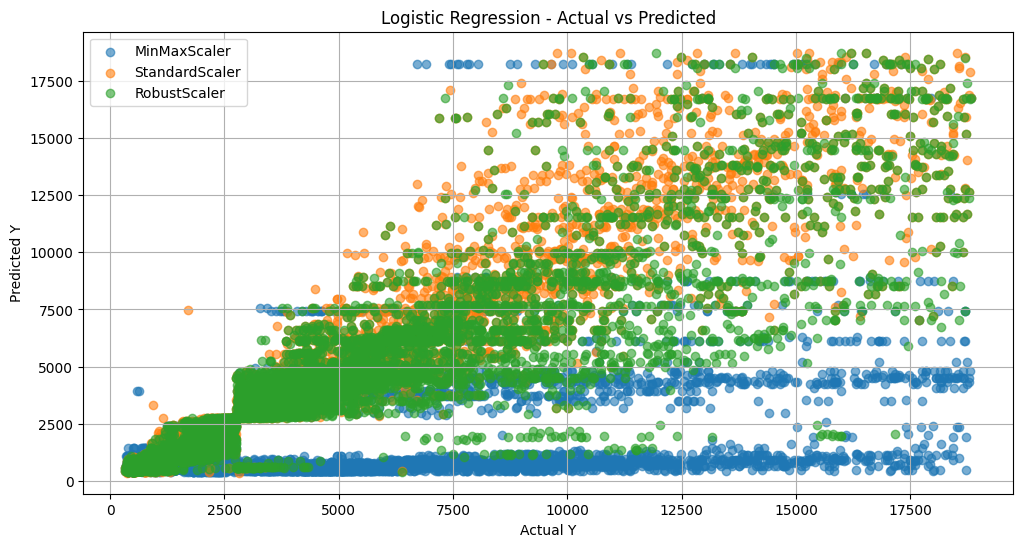

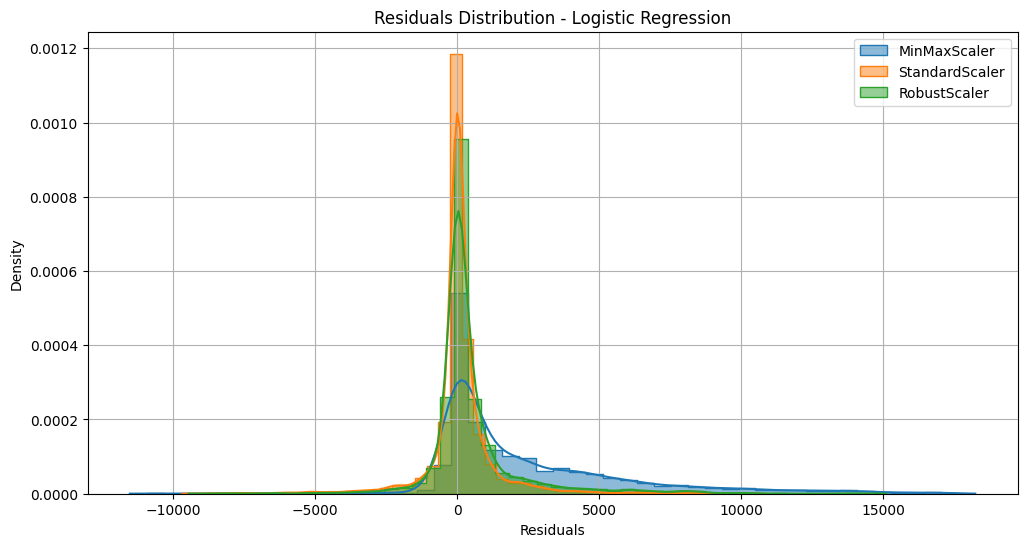

In [10]:
# Logistic Regression for each preprocessing method
# Dictionary to store predictions and residuals for combined plots
predictions = {}
residuals = {}

# Lista de tuplas contendo os diferentes conjuntos de dados escalonados
scaled_datasets = [
    ('MinMaxScaler', normalized_data_train, normalized_data_test),
    ('StandardScaler', standard_data_train, standard_data_test),
    ('RobustScaler', robust_data_train, robust_data_test)
]

for method, X_train_scaled, X_test_scaled in scaled_datasets:
    print(f"Method: {method}")
    
    # Strating the Logistic Regression model
    lm = LogisticRegression()
    
    # Training the model
    lm.fit(X_train_scaled, y_train)
    
    # Make predictions
    pred = lm.predict(X_test_scaled)
    predictions[method] = (y_test, pred)
    residuals[method] = y_test - pred

    # Evaluation metrics
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print('\nClassification Report:')
    print(classification_report(y_test, pred))

    print('MAE:', round(mean_absolute_error(y_test, pred), 3))
    print('MSE:', round(mean_squared_error(y_test, pred), 3))
    print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))
    print('\n' + '-'*80 + '\n')


# Plot all scatter plots in one figure
plt.figure(figsize=(12, 6))
for method, (y_test, pred) in predictions.items():
    plt.scatter(y_test, pred, label=method, alpha=0.6)
plt.title('Logistic Regression - Actual vs Predicted')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.legend()
plt.grid(True)
plt.show()

# Plot all residual histograms in one figure
plt.figure(figsize=(12, 6))
for method, resid in residuals.items():
    sns.histplot(resid, bins=50, kde=True, label=method, stat='density', element='step')
plt.title('Residuals Distribution - Logistic Regression')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

Knn

c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Best k for MinMaxScaler: 1
Error rate for MinMaxScaler: 0.27
Confusion Matrix:
[[0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 1 0 0]]

Classification Report:
              precision    recall  f1-score   support

       335.0       0.00      0.00      0.00         1
       336.0       0.33      1.00      0.50         1
       337.0       0.00      0.00      0.00         1
       357.0       1.00      0.67      0.80         3
       358.0       0.00      0.00      0.00         1
       360.0       0.50      1.00      0.67         1
       361.0       0.00      0.00      0.00         1
       362.0       0.00      0.00      0.00         0
       363.0       1.00      0.50      0.67         2
       364.0       0.50      1.00      0.67         1
       365.0       0.00      0.00      0.00         0
       367.0       0.67      0.50      0.57         4
       368.0       1.00      0.50      0.67         2
       369.0       1

c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

Best k for StandardScaler: 1
Error rate for StandardScaler: 0.27
Confusion Matrix:
[[0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 1 0 0]]

Classification Report:
              precision    recall  f1-score   support

       335.0       0.00      0.00      0.00         1
       336.0       0.33      1.00      0.50         1
       337.0       0.00      0.00      0.00         1
       357.0       1.00      0.67      0.80         3
       358.0       0.00      0.00      0.00         1
       360.0       0.50      1.00      0.67         1
       361.0       0.00      0.00      0.00         1
       362.0       0.00      0.00      0.00         0
       363.0       1.00      0.50      0.67         2
       364.0       0.50      1.00      0.67         1
       365.0       0.00      0.00      0.00         0
       367.0       0.67      0.50      0.57         4
       368.0       1.00      0.50      0.67         2
       369.0    

c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

Best k for RobustScaler: 1
Error rate for RobustScaler: 0.27
Confusion Matrix:
[[0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 1 0 0]]

Classification Report:


c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hélio Henrique\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

              precision    recall  f1-score   support

       335.0       0.00      0.00      0.00         1
       336.0       0.33      1.00      0.50         1
       337.0       0.00      0.00      0.00         1
       357.0       1.00      0.67      0.80         3
       358.0       0.00      0.00      0.00         1
       360.0       0.50      1.00      0.67         1
       361.0       0.00      0.00      0.00         1
       362.0       0.00      0.00      0.00         0
       363.0       1.00      0.50      0.67         2
       364.0       0.50      1.00      0.67         1
       365.0       0.00      0.00      0.00         0
       367.0       0.67      0.50      0.57         4
       368.0       1.00      0.50      0.67         2
       369.0       1.00      1.00      1.00         1
       373.0       1.00      1.00      1.00         3
       377.0       0.50      1.00      0.67         1
       378.0       1.00      0.67      0.80         3
       380.0       1.00    

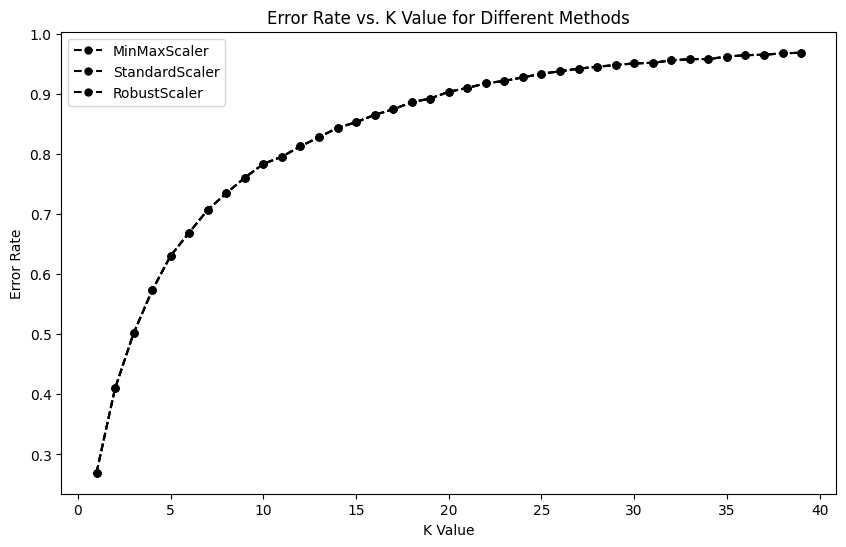

In [11]:
# KNN Classifier
# Initialize the KNN classifier

# Dictionary to store error rates for each method
error_rates_dict = {}

# Lista de tuplas contendo os diferentes conjuntos de dados escalonados
scaled_datasets = [
    ('MinMaxScaler', normalized_data_train, normalized_data_test),
    ('StandardScaler', standard_data_train, standard_data_test),
    ('RobustScaler', robust_data_train, robust_data_test)
]

for method, X_train_scaled, X_test_scaled in scaled_datasets:
    error_rate = []

    # Finding the best K value by iterating K from 1 to 39
    for k in range(1, 40):
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train, y_train)
        pred_i = knn.predict(X_test)
        error_rate.append(np.mean(pred_i != y_test))
    
    # Store the error rate curve for this method
    error_rates_dict[method] = error_rate

    # Determine the best K (adding +1 because k starts at 1)
    best_k = np.argmin(error_rate) + 1
    print(f"Best k for {method}: {best_k}")
    print(f"Error rate for {method}: {round(min(error_rate), 3)}")

    # Train KNN with the best k and evaluate the model
    knn_best_k = KNeighborsRegressor(n_neighbors=best_k)
    knn_best_k.fit(X_train, y_train)
    pred_best_k = knn_best_k.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred_best_k))
    print("\nClassification Report:")
    print(classification_report(y_test, pred_best_k))

    # Calculate error metrics
    print('MAE:', round(mean_absolute_error(y_test, pred_best_k), 3))
    print('MSE:', round(mean_squared_error(y_test, pred_best_k), 3))
    print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_best_k)), 3))
    print("\n" + "-"*80 + "\n")

# Plot all error rate curves in one plot
plt.figure(figsize=(10, 6))

# Define colors for each method
colors = {'NormalizedData': 'blue', 'StandardData': 'green', 'RobustData': 'red'}

for method, error_rate in error_rates_dict.items():
    plt.plot(range(1, 40), error_rate, linestyle='dashed', marker='o',
             markerfacecolor=colors.get(method, 'black'), markersize=5,
             color=colors.get(method, 'black'), label=method)

plt.title('Error Rate vs. K Value for Different Methods')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.legend()
plt.show()